In [2]:
import pandas as pd
from datetime import datetime
from IPython.display import display
import os
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('/content/CSAW-CC_breast_cancer_screening_data.csv')
df = df.drop(columns = ['x_cancer_laterality', 'x_type','x_age','x_lymphnode_met', 'rad_recall','rad_recall_type_left','x_case', 'rad_r1', 'rad_r2', 'rad_recall_type_right'])
display(df)

,anon_patientid,exam_year,anon_filename,rad_timing,imagelaterality,viewposition,libra_breastarea,libra_densearea,libra_percentdensity
0,2,2015,00002_20990909_L_CC_1.dcm,2.0,Left,CC,127.258090,29.595217,23.256058
1,2,2015,00002_20990909_L_MLO_1.dcm,2.0,Left,MLO,122.318120,39.298000,32.127705
2,2,2015,00002_20990909_R_CC_1.dcm,2.0,Right,CC,114.570630,23.637600,20.631468
3,2,2015,00002_20990909_R_MLO_1.dcm,2.0,Right,MLO,133.202380,36.162785,27.148750
4,4,2012,00004_20990909_R_CC_1.dcm,NaN,Right,CC,201.187730,68.998276,34.295467
...,...,...,...,...,...,...,...,...,...
98783,11301,2015,11301_20990909_R_CC_1.dcm,NaN,Right,CC,69.278275,24.969255,36.041973
98784,11303,2014,11303_20990909_R_CC_1.dcm,1.0,Right,CC,196.125440,33.502670,17.082268
98785,11303,2014,11303_20990909_L_MLO_1.dcm,1.0,Left,MLO,257.890530,15.262912,5.918369
98786,11303,2014,11303_20990909_R_MLO_1.dcm,1.0,Right,MLO,232.718640,14.388752,6.182896


In [4]:
cancer_years = {}

# Step 1: Identify cancer year for each patient
cancer_years = {}
for patient_id, group in df.groupby("anon_patientid"):
    # Get the most recent exam year for this patient
    most_recent_exam = group.loc[group['exam_year'].idxmax()]

    rad_timing = most_recent_exam['rad_timing']

    # Step 2: Calculate cancer year based on rad_timing
    if rad_timing == 1:  # Screen-detected cancer (within 60 days)
        cancer_years[patient_id] = most_recent_exam['exam_year']
    elif rad_timing == 2:  # Interval cancer (60-729 days)
        # If the last exam year is 2013, set cancer year to 2015
        cancer_years[patient_id] = most_recent_exam['exam_year'] +1
        if most_recent_exam['exam_year'] == 2015:
            cancer_years[patient_id] = 2016

# Step 3: Calculate years to cancer for each image
df["years_to_cancer"] = df.apply(lambda row: (
    cancer_years.get(row["anon_patientid"], None) - row["exam_year"]
    if row["anon_patientid"] in cancer_years else None
), axis=1)

# Step 4: Calculate years to last follow-up (based on the latest exam year for each patient)
latest_exam_years = df.groupby("anon_patientid")["exam_year"].max()
df["years_to_last_followup"] = df.apply(lambda row: (
    latest_exam_years[row["anon_patientid"]] - row["exam_year"]
), axis=1)

# Output the final DataFrame with calculated values

display(df)

,anon_patientid,exam_year,anon_filename,rad_timing,imagelaterality,viewposition,libra_breastarea,libra_densearea,libra_percentdensity,years_to_cancer,years_to_last_followup
0,2,2015,00002_20990909_L_CC_1.dcm,2.0,Left,CC,127.258090,29.595217,23.256058,1.0,0
1,2,2015,00002_20990909_L_MLO_1.dcm,2.0,Left,MLO,122.318120,39.298000,32.127705,1.0,0
2,2,2015,00002_20990909_R_CC_1.dcm,2.0,Right,CC,114.570630,23.637600,20.631468,1.0,0
3,2,2015,00002_20990909_R_MLO_1.dcm,2.0,Right,MLO,133.202380,36.162785,27.148750,1.0,0
4,4,2012,00004_20990909_R_CC_1.dcm,NaN,Right,CC,201.187730,68.998276,34.295467,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...
98783,11301,2015,11301_20990909_R_CC_1.dcm,NaN,Right,CC,69.278275,24.969255,36.041973,NaN,0
98784,11303,2014,11303_20990909_R_CC_1.dcm,1.0,Right,CC,196.125440,33.502670,17.082268,0.0,0
98785,11303,2014,11303_20990909_L_MLO_1.dcm,1.0,Left,MLO,257.890530,15.262912,5.918369,0.0,0
98786,11303,2014,11303_20990909_R_MLO_1.dcm,1.0,Right,MLO,232.718640,14.388752,6.182896,0.0,0


In [5]:
df_filtered = df.groupby('anon_patientid').filter(lambda x: x['exam_year'].nunique() > 1)
df_filtered['years_to_cancer'] = df_filtered['years_to_cancer'].fillna(100)


In [7]:
# Step 1: Identify cancer-free patients with at least 5 years of follow-up
cancer_free_patients = df_filtered[df_filtered['years_to_cancer'] == 100]
follow_up_period = cancer_free_patients.groupby('anon_patientid')['exam_year'].agg(['min', 'max'])
follow_up_period['duration_years'] = follow_up_period['max'] - follow_up_period['min']

# Select patients with at least 5 years of follow-up
patients_with_5_years = follow_up_period[follow_up_period['duration_years'] >= 5].index
# Step 2: Identify patients with years_to_cancer in [1, 2, 3, 4, 5]
cancer_patients = df_filtered[df_filtered['years_to_cancer'].isin([0,1, 2, 3, 4, 5])]['anon_patientid'].unique()

# Step 3: Combine both groups of patients
valid_patients = set(patients_with_5_years).union(set(cancer_patients))

# Step 4: Apply filtering to keep only the selected patients
df_filtered_new = df_filtered[df_filtered['anon_patientid'].isin(valid_patients)].reset_index(drop=True)
csaw_cc_filtered = df_filtered_new[(df_filtered_new['years_to_cancer'] <= 5) | (df_filtered_new['years_to_cancer'] == 100)]

# Display the filtered dataset
display(csaw_cc_filtered)

,anon_patientid,exam_year,anon_filename,rad_timing,imagelaterality,viewposition,libra_breastarea,libra_densearea,libra_percentdensity,years_to_cancer,years_to_last_followup
0,5,2009,00005_20990909_L_CC_1.dcm,NaN,Left,CC,244.08507,66.800720,27.367802,100.0,7
1,5,2009,00005_20990909_L_MLO_1.dcm,NaN,Left,MLO,239.10275,27.663441,11.569687,100.0,7
2,5,2009,00005_20990909_R_MLO_4.dcm,NaN,Right,MLO,317.13113,20.048449,6.321816,100.0,7
3,5,2009,00005_20990909_R_CC_1.dcm,NaN,Right,CC,322.41452,40.009872,12.409451,100.0,7
4,5,2011,00005_20990909_L_CC_2.dcm,NaN,Left,CC,272.92294,49.659344,18.195372,100.0,5
...,...,...,...,...,...,...,...,...,...,...,...
67679,11067,2008,11067_20990909_R_MLO_2.dcm,3.0,Right,MLO,252.23004,31.744160,12.585400,4.0,4
67680,11067,2012,11067_20990909_R_MLO_1.dcm,1.0,Right,MLO,223.90413,29.157743,13.022424,0.0,0
67681,11067,2012,11067_20990909_L_MLO_1.dcm,1.0,Left,MLO,261.45538,23.506672,8.990701,0.0,0
67682,11067,2012,11067_20990909_R_CC_1.dcm,1.0,Right,CC,223.48390,22.960224,10.273771,0.0,0


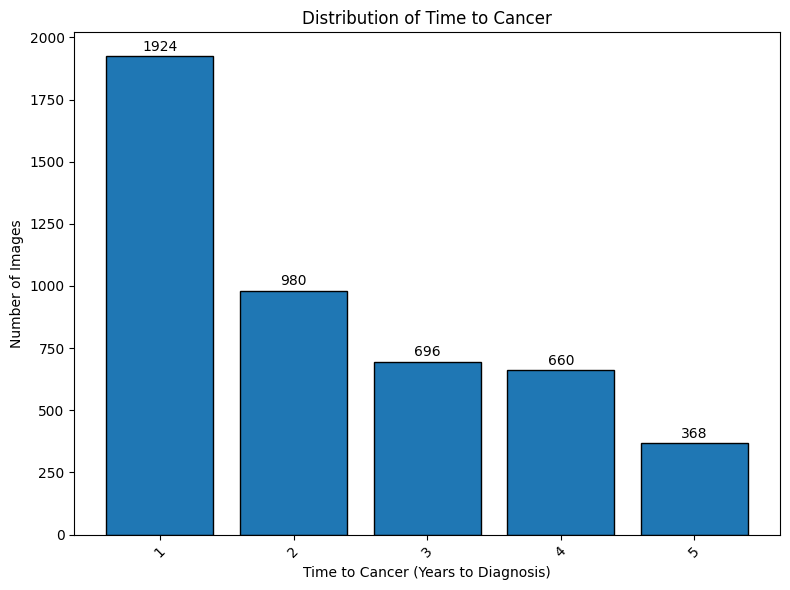

In [8]:
#csaw_cc_filtered.loc[csaw_cc_filtered['years_to_cancer'] == 0, 'years_to_cancer'] = 1

# Count the occurrences of each "years_to_cancer" value (2, 3, 4, 5)
counts = {    1: len(csaw_cc_filtered[csaw_cc_filtered['years_to_cancer'] == 1]) + len(csaw_cc_filtered[csaw_cc_filtered['years_to_cancer'] == 0]),
    2: len(csaw_cc_filtered[csaw_cc_filtered['years_to_cancer'] == 2]),
    3: len(csaw_cc_filtered[csaw_cc_filtered['years_to_cancer'] == 3]),
    4: len(csaw_cc_filtered[csaw_cc_filtered['years_to_cancer'] == 4]),
    5: len(csaw_cc_filtered[csaw_cc_filtered['years_to_cancer'] == 5]),
}

# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the bar chart with the counts for each year value (2Y, 3Y, 4Y, 5Y)
ax.bar(counts.keys(), counts.values(), edgecolor='black')

# Labeling the plot
ax.set_xlabel('Time to Cancer (Years to Diagnosis)')
ax.set_ylabel('Number of Images')
ax.set_title('Distribution of Time to Cancer')

# Add values above the bars
for i, value in enumerate(counts.values()):
    ax.text(list(counts.keys())[i], value + 10, str(value), ha='center', va='bottom', fontsize=10)

# Rotate x-axis labels for better readability
ax.tick_params(axis='x', rotation=45)

# Display the plot
plt.tight_layout()
plt.show()


In [9]:

csaw_cc_filtered =  csaw_cc_filtered.rename(columns={'anon_patientid': 'patient_id', 'anon_filename': 'file_name', 'imagelaterality':'laterality'})
display(csaw_cc_filtered)

,patient_id,exam_year,file_name,rad_timing,laterality,viewposition,libra_breastarea,libra_densearea,libra_percentdensity,years_to_cancer,years_to_last_followup
0,5,2009,00005_20990909_L_CC_1.dcm,NaN,Left,CC,244.08507,66.800720,27.367802,100.0,7
1,5,2009,00005_20990909_L_MLO_1.dcm,NaN,Left,MLO,239.10275,27.663441,11.569687,100.0,7
2,5,2009,00005_20990909_R_MLO_4.dcm,NaN,Right,MLO,317.13113,20.048449,6.321816,100.0,7
3,5,2009,00005_20990909_R_CC_1.dcm,NaN,Right,CC,322.41452,40.009872,12.409451,100.0,7
4,5,2011,00005_20990909_L_CC_2.dcm,NaN,Left,CC,272.92294,49.659344,18.195372,100.0,5
...,...,...,...,...,...,...,...,...,...,...,...
67679,11067,2008,11067_20990909_R_MLO_2.dcm,3.0,Right,MLO,252.23004,31.744160,12.585400,4.0,4
67680,11067,2012,11067_20990909_R_MLO_1.dcm,1.0,Right,MLO,223.90413,29.157743,13.022424,0.0,0
67681,11067,2012,11067_20990909_L_MLO_1.dcm,1.0,Left,MLO,261.45538,23.506672,8.990701,0.0,0
67682,11067,2012,11067_20990909_R_CC_1.dcm,1.0,Right,CC,223.48390,22.960224,10.273771,0.0,0


In [ ]:
csaw_cc_filtered['anon_dicom_path_local'] = '/storage/csaw_cc_data_full/2021-204-1-1/data/' + csaw_cc_filtered['file_name']
display(csaw_cc_filtered)

,patient_id,exam_year,file_name,rad_timing,laterality,viewposition,libra_breastarea,libra_densearea,libra_percentdensity,years_to_cancer,years_to_last_followup,anon_dicom_path_local
68,12,2009,00012_20990909_L_CC_2.dcm,3.0,Left,CC,87.053009,36.376034,41.786072,5.0,4,/storage/csaw_cc_data_full/2021-204-1-1/data/0...
69,12,2009,00012_20990909_L_MLO_2.dcm,3.0,Left,MLO,137.335630,38.811134,28.260063,5.0,4,/storage/csaw_cc_data_full/2021-204-1-1/data/0...
70,12,2009,00012_20990909_R_CC_2.dcm,3.0,Right,CC,95.775795,35.388191,36.948994,5.0,4,/storage/csaw_cc_data_full/2021-204-1-1/data/0...
71,12,2009,00012_20990909_R_MLO_2.dcm,3.0,Right,MLO,124.887280,50.099953,40.116138,5.0,4,/storage/csaw_cc_data_full/2021-204-1-1/data/0...
72,12,2010,00012_20990909_L_CC_4.dcm,3.0,Left,CC,136.760960,35.817825,26.190094,4.0,3,/storage/csaw_cc_data_full/2021-204-1-1/data/0...
...,...,...,...,...,...,...,...,...,...,...,...,...
67679,11067,2008,11067_20990909_R_MLO_2.dcm,3.0,Right,MLO,252.230040,31.744160,12.585400,4.0,4,/storage/csaw_cc_data_full/2021-204-1-1/data/1...
67680,11067,2012,11067_20990909_R_MLO_1.dcm,1.0,Right,MLO,223.904130,29.157743,13.022424,0.0,0,/storage/csaw_cc_data_full/2021-204-1-1/data/1...
67681,11067,2012,11067_20990909_L_MLO_1.dcm,1.0,Left,MLO,261.455380,23.506672,8.990701,0.0,0,/storage/csaw_cc_data_full/2021-204-1-1/data/1...
67682,11067,2012,11067_20990909_R_CC_1.dcm,1.0,Right,CC,223.483900,22.960224,10.273771,0.0,0,/storage/csaw_cc_data_full/2021-204-1-1/data/1...


In [11]:
csaw_cc_filtered['file_name'] = csaw_cc_filtered['file_name'].str.replace('.dcm', '.png', regex=False)
display(csaw_cc_filtered)

,patient_id,exam_year,file_name,rad_timing,laterality,viewposition,libra_breastarea,libra_densearea,libra_percentdensity,years_to_cancer,years_to_last_followup,split_group
0,5,2009,00005_20990909_L_CC_1.png,NaN,Left,CC,244.08507,66.800720,27.367802,100.0,7,train
1,5,2009,00005_20990909_L_MLO_1.png,NaN,Left,MLO,239.10275,27.663441,11.569687,100.0,7,train
2,5,2009,00005_20990909_R_MLO_4.png,NaN,Right,MLO,317.13113,20.048449,6.321816,100.0,7,train
3,5,2009,00005_20990909_R_CC_1.png,NaN,Right,CC,322.41452,40.009872,12.409451,100.0,7,train
4,5,2011,00005_20990909_L_CC_2.png,NaN,Left,CC,272.92294,49.659344,18.195372,100.0,5,train
...,...,...,...,...,...,...,...,...,...,...,...,...
67679,11067,2008,11067_20990909_R_MLO_2.png,3.0,Right,MLO,252.23004,31.744160,12.585400,4.0,4,val
67680,11067,2012,11067_20990909_R_MLO_1.png,1.0,Right,MLO,223.90413,29.157743,13.022424,0.0,0,val
67681,11067,2012,11067_20990909_L_MLO_1.png,1.0,Left,MLO,261.45538,23.506672,8.990701,0.0,0,val
67682,11067,2012,11067_20990909_R_CC_1.png,1.0,Right,CC,223.48390,22.960224,10.273771,0.0,0,val


In [12]:
from sklearn.model_selection import train_test_split

# Group the data by 'years_to_cancer'
grouped = csaw_cc_filtered.groupby('years_to_cancer')

# Empty lists to store splits

# First, we group the data by `patient_id` to ensure patients are only in one split
patients = csaw_cc_filtered['patient_id'].unique()

# Split the patients into train, validation, and test sets

train_patients, temp_patients = train_test_split(patients, test_size=0.5, stratify=csaw_cc_filtered.groupby('patient_id')['years_to_cancer'].first()[patients])
val_patients, test_patients = train_test_split(temp_patients, test_size=0.6, stratify=csaw_cc_filtered.groupby('patient_id')['years_to_cancer'].first()[temp_patients])

# Now, we can add the `split_group` to the original DataFrame based on patient assignment
csaw_cc_filtered['split_group'] = None
csaw_cc_filtered.loc[csaw_cc_filtered['patient_id'].isin(train_patients), 'split_group'] = 'train'
csaw_cc_filtered.loc[csaw_cc_filtered['patient_id'].isin(val_patients), 'split_group'] = 'val'
csaw_cc_filtered.loc[csaw_cc_filtered['patient_id'].isin(test_patients), 'split_group'] = 'test'

# Verify that the `split_group` is properly assigned and the distribution of `years_to_cancer` is preserved
print(csaw_cc_filtered.groupby(['split_group', 'years_to_cancer']).size())

# Verify the distribution and the new 'split_group' column


split_group  years_to_cancer
test         0.0                  384
             1.0                  184
             2.0                  312
             3.0                  200
             4.0                  204
             5.0                  112
             100.0              18804
train        0.0                  612
             1.0                  348
             2.0                  480
             3.0                  336
             4.0                  324
             5.0                  184
             100.0              31376
val          0.0                  224
             1.0                  172
             2.0                  188
             3.0                  160
             4.0                  132
             5.0                   72
             100.0              12376
dtype: int64


In [13]:
bins = [0, 33, 67, 100]  # Bin edges
labels = ['0-33', '33-67', '67-100']  # Corresponding labels

# Create the 'density' column
csaw_cc_filtered['density'] = pd.cut(csaw_cc_filtered['libra_percentdensity'], bins=bins, labels=labels, include_lowest=True)
display(csaw_cc_filtered)

,patient_id,exam_year,file_name,rad_timing,laterality,viewposition,libra_breastarea,libra_densearea,libra_percentdensity,years_to_cancer,years_to_last_followup,split_group,density
0,5,2009,00005_20990909_L_CC_1.png,NaN,Left,CC,244.08507,66.800720,27.367802,100.0,7,test,0-33
1,5,2009,00005_20990909_L_MLO_1.png,NaN,Left,MLO,239.10275,27.663441,11.569687,100.0,7,test,0-33
2,5,2009,00005_20990909_R_MLO_4.png,NaN,Right,MLO,317.13113,20.048449,6.321816,100.0,7,test,0-33
3,5,2009,00005_20990909_R_CC_1.png,NaN,Right,CC,322.41452,40.009872,12.409451,100.0,7,test,0-33
4,5,2011,00005_20990909_L_CC_2.png,NaN,Left,CC,272.92294,49.659344,18.195372,100.0,5,test,0-33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67679,11067,2008,11067_20990909_R_MLO_2.png,3.0,Right,MLO,252.23004,31.744160,12.585400,4.0,4,test,0-33
67680,11067,2012,11067_20990909_R_MLO_1.png,1.0,Right,MLO,223.90413,29.157743,13.022424,0.0,0,test,0-33
67681,11067,2012,11067_20990909_L_MLO_1.png,1.0,Left,MLO,261.45538,23.506672,8.990701,0.0,0,test,0-33
67682,11067,2012,11067_20990909_R_CC_1.png,1.0,Right,CC,223.48390,22.960224,10.273771,0.0,0,test,0-33


In [15]:
csaw_cc_filtered.to_csv('/content/metadata_csawcc_dcm_path.csv', index=False)
